In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import streamlit as st
import joblib 

In [2]:
df=pd.read_csv('dataset.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [4]:
df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'Id'], errors='ignore')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   LotShape       1460 non-null   str    
 6   LandContour    1460 non-null   str    
 7   Utilities      1460 non-null   str    
 8   LotConfig      1460 non-null   str    
 9   LandSlope      1460 non-null   str    
 10  Neighborhood   1460 non-null   str    
 11  Condition1     1460 non-null   str    
 12  Condition2     1460 non-null   str    
 13  BldgType       1460 non-null   str    
 14  HouseStyle     1460 non-null   str    
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd   1460

In [5]:
c_cols=df.select_dtypes(include=['object','category']).columns
print(c_cols)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\thesa\AppData\Local\Temp\ipykernel_39896\324564232.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c_cols=df.select_dtypes(include=['object','category']).columns


In [6]:
for col in c_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [7]:
df.head(15)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450,1,3,3,0,4,0,...,0,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,0,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,0,0,0,0,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,0,0,0,0,0,12,2008,8,4,250000
5,50,3,85.0,14115,1,0,3,0,4,0,...,0,320,0,0,700,10,2009,8,4,143000
6,20,3,75.0,10084,1,3,3,0,4,0,...,0,0,0,0,0,8,2007,8,4,307000
7,60,3,NaN,10382,1,0,3,0,0,0,...,228,0,0,0,350,11,2009,8,4,200000
8,50,4,51.0,6120,1,3,3,0,4,0,...,205,0,0,0,0,4,2008,8,0,129900
9,190,3,50.0,7420,1,3,3,0,0,0,...,0,0,0,0,0,1,2008,8,4,118000


<Axes: >

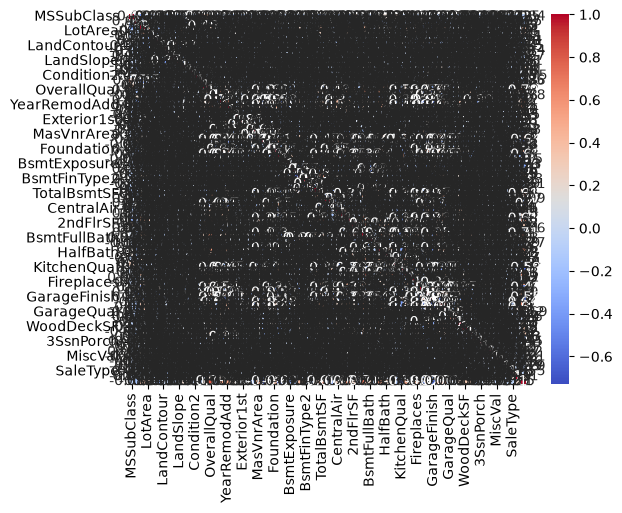

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [9]:
correlated_feaatures=df.corr()['SalePrice'].sort_values(ascending=False)

In [10]:
correlated_features = correlated_feaatures[correlated_feaatures>0.25]
df=df[correlated_features.index]

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     1460 non-null   int64  
 1   OverallQual   1460 non-null   int64  
 2   GrLivArea     1460 non-null   int64  
 3   GarageCars    1460 non-null   int64  
 4   GarageArea    1460 non-null   int64  
 5   TotalBsmtSF   1460 non-null   int64  
 6   1stFlrSF      1460 non-null   int64  
 7   FullBath      1460 non-null   int64  
 8   TotRmsAbvGrd  1460 non-null   int64  
 9   YearBuilt     1460 non-null   int64  
 10  YearRemodAdd  1460 non-null   int64  
 11  GarageYrBlt   1379 non-null   float64
 12  MasVnrArea    1452 non-null   float64
 13  Fireplaces    1460 non-null   int64  
 14  BsmtFinSF1    1460 non-null   int64  
 15  Foundation    1460 non-null   int64  
 16  LotFrontage   1201 non-null   float64
 17  WoodDeckSF    1460 non-null   int64  
 18  2ndFlrSF      1460 non-null   int64  
 

<Axes: >

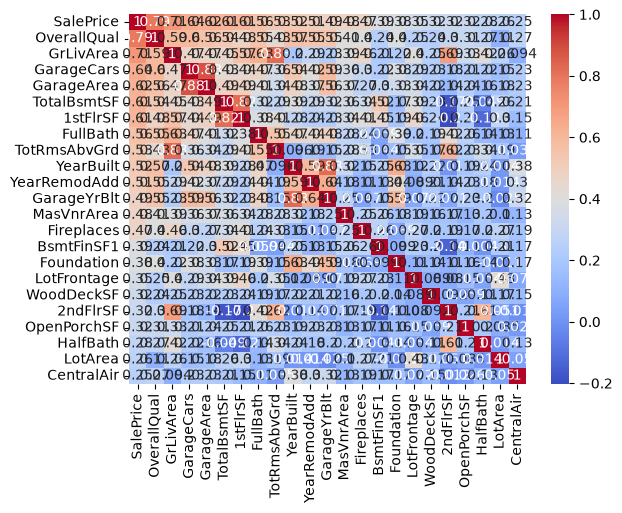

In [12]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')     

In [13]:
df[df.corr()['SalePrice'].sort_values(ascending=False).head(16).index]

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,Foundation
0,208500,7,1710,2,548,856,856,2,8,2003,2003,2003.0,196.0,0,706,2
1,181500,6,1262,2,460,1262,1262,2,6,1976,1976,1976.0,0.0,1,978,1
2,223500,7,1786,2,608,920,920,2,6,2001,2002,2001.0,162.0,1,486,2
3,140000,7,1717,3,642,756,961,1,7,1915,1970,1998.0,0.0,1,216,0
4,250000,8,2198,3,836,1145,1145,2,9,2000,2000,2000.0,350.0,1,655,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,460,953,953,2,7,1999,2000,1999.0,0.0,1,0,2
1456,210000,6,2073,2,500,1542,2073,2,7,1978,1988,1978.0,119.0,2,790,1
1457,266500,7,2340,1,252,1152,1188,2,9,1941,2006,1941.0,0.0,2,275,4
1458,142125,5,1078,1,240,1078,1078,1,5,1950,1996,1950.0,0.0,0,49,1


In [14]:
df.isnull().sum()

SalePrice         0
OverallQual       0
GrLivArea         0
GarageCars        0
GarageArea        0
TotalBsmtSF       0
1stFlrSF          0
FullBath          0
TotRmsAbvGrd      0
YearBuilt         0
YearRemodAdd      0
GarageYrBlt      81
MasVnrArea        8
Fireplaces        0
BsmtFinSF1        0
Foundation        0
LotFrontage     259
WoodDeckSF        0
2ndFlrSF          0
OpenPorchSF       0
HalfBath          0
LotArea           0
CentralAir        0
dtype: int64

In [15]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean(), inplace=True)
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean(), inplace=True)

C:\Users\thesa\AppData\Local\Temp\ipykernel_39896\3609505068.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['GarageYrBlt']=df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean(), inplace=True)
C:\Users\thesa\AppData\Local\Temp\ipykernel_39896\3609505068.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     1460 non-null   int64  
 1   OverallQual   1460 non-null   int64  
 2   GrLivArea     1460 non-null   int64  
 3   GarageCars    1460 non-null   int64  
 4   GarageArea    1460 non-null   int64  
 5   TotalBsmtSF   1460 non-null   int64  
 6   1stFlrSF      1460 non-null   int64  
 7   FullBath      1460 non-null   int64  
 8   TotRmsAbvGrd  1460 non-null   int64  
 9   YearBuilt     1460 non-null   int64  
 10  YearRemodAdd  1460 non-null   int64  
 11  GarageYrBlt   1460 non-null   float64
 12  MasVnrArea    1452 non-null   float64
 13  Fireplaces    1460 non-null   int64  
 14  BsmtFinSF1    1460 non-null   int64  
 15  Foundation    1460 non-null   int64  
 16  LotFrontage   1460 non-null   float64
 17  WoodDeckSF    1460 non-null   int64  
 18  2ndFlrSF      1460 non-null   int64  
 

In [17]:
x=df.drop(columns=['SalePrice'], errors='ignore')
y=df['SalePrice']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
from xgboost import XGBRegressor

In [22]:
model= XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    random_state=67,
    subsample=0.8,
    max_depth=6,
    learning_rate=0.1

)
model.fit(x_train, y_train)
prediction = model.predict(x_test)

In [25]:
print("Mean Squared Error:", mean_squared_error(y_test, prediction))
print("R2 Score:", r2_score(y_test, prediction))
rmse = np.sqrt(mean_squared_error(y_test, prediction))
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 678260608.0
R2 Score: 0.9115734100341797
Root Mean Squared Error: 26043.436946762613


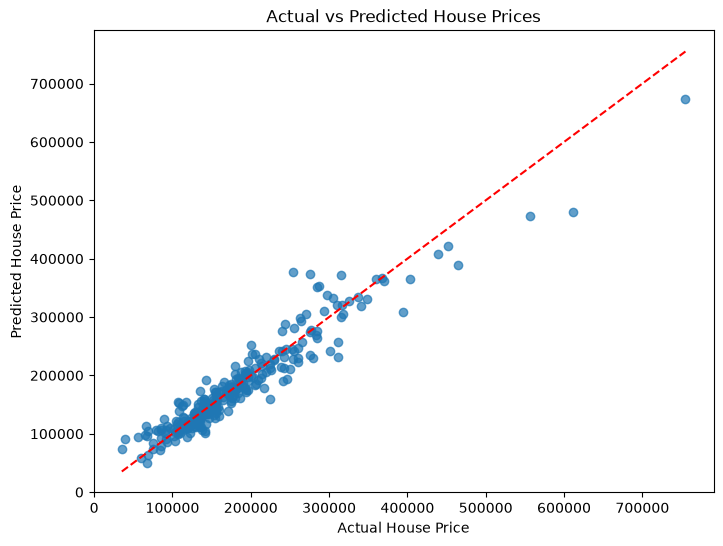

In [26]:


plt.figure(figsize=(8,6))
plt.scatter(y_test, prediction, alpha=0.7)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()